In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------
# 1. Define Lightweight Vision Transformer
# ----------------------------
class PretrainedViT_Tiny(nn.Module):
    def __init__(self, model_name="vit_tiny_patch16_224", num_classes=1):
        super().__init__()
        self.base_model = timm.create_model(model_name, pretrained=True)
        in_features = self.base_model.head.in_features
        self.base_model.head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.base_model(x)

# ----------------------------
# 2. Data Loading
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),   # match pretrained ViT input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
'''
transform = transforms.Compose([
    transforms.Resize((128,128)),   # smaller resolution -> faster training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
'''
# root folder containing two subfolders: Healthy, Diseased
dataset = datasets.ImageFolder("/content/drive/MyDrive/Chroma", transform=transform)

# Get labels for StratifiedKFold
labels = np.array(dataset.targets)

# ----------------------------
# 3. 5-Fold Cross-Validation
# ----------------------------
skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n===== Fold {fold+1} =====")

    train_subset = Subset(dataset, train_idx)
    val_subset   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=10, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=10, shuffle=False)

    # Model, Loss, Optimizer
    model = PretrainedViT_Tiny().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-5)

    train_acc, val_acc, train_loss, val_loss = [], [], [], []

    # ---------------- Training ----------------
    for epoch in range(10):  # exactly 13 epochs per fold
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for imgs, labels_batch in train_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = (outputs > 0.5).int()
            correct += (preds == labels_batch.int()).sum().item()
            total += labels_batch.size(0)

        train_acc.append(100 * correct / total)
        train_loss.append(epoch_loss / len(train_loader))

        # Validation
        model.eval()
        correct, total, epoch_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels_batch in val_loader:
                imgs, labels_batch = imgs.to(device), labels_batch.to(device).float().unsqueeze(1)
                outputs = model(imgs)
                loss = criterion(outputs, labels_batch)

                epoch_loss += loss.item()
                preds = (outputs > 0.5).int()
                correct += (preds == labels_batch.int()).sum().item()
                total += labels_batch.size(0)

        val_acc.append(100 * correct / total)
        val_loss.append(epoch_loss / len(val_loader))

        print(f"Epoch [{epoch+1}/13], Train Acc: {train_acc[-1]:.4f}%, Val Acc: {val_acc[-1]:.4f}%")

    # ---------------- Evaluation ----------------
    y_true, y_pred, y_scores = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy().ravel()
            preds = (outputs > 0.5).astype(int)
            y_scores.extend(outputs)
            y_pred.extend(preds)
            y_true.extend(labels_batch.numpy())

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=dataset.classes))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
    plt.title(f"Confusion Matrix (Fold {fold+1})")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Accuracy curves
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Training and Validation Accuracy (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Loss curves
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Save fold results
    fold_results.append({
        "fold": fold+1,
        "val_acc": val_acc[-1],
        "roc_auc": roc_auc
    })

# ----------------------------
# 4. Final Summary
# ----------------------------
print("\n===== Cross-Validation Summary =====")
for r in fold_results:
    print(f"Fold {r['fold']}: Val Acc = {r['val_acc']:.4f}%, AUC = {r['roc_auc']:.4f}")

mean_acc = np.mean([r["val_acc"] for r in fold_results])
mean_auc = np.mean([r["roc_auc"] for r in fold_results])
print(f"\nAverage Val Accuracy: {mean_acc:.4f}%")
print(f"Average AUC: {mean_auc:.4f}")



===== Fold 1 =====
Epoch [1/13], Train Acc: 56.6265%, Val Acc: 78.1250%
Epoch [2/13], Train Acc: 74.9398%, Val Acc: 90.1442%
Epoch [3/13], Train Acc: 98.0723%, Val Acc: 100.0000%


KeyboardInterrupt: 


===== Fold 1 =====
Epoch [1/10], Train Acc: 48.3755%, Val Acc: 52.7076%
Epoch [2/10], Train Acc: 51.6245%, Val Acc: 52.7076%
Epoch [3/10], Train Acc: 56.3177%, Val Acc: 55.2347%
Epoch [4/10], Train Acc: 61.1913%, Val Acc: 64.6209%
Epoch [5/10], Train Acc: 73.4657%, Val Acc: 53.0686%
Epoch [6/10], Train Acc: 69.3141%, Val Acc: 78.7004%
Epoch [7/10], Train Acc: 79.6029%, Val Acc: 69.3141%
Epoch [8/10], Train Acc: 79.2419%, Val Acc: 66.7870%
Epoch [9/10], Train Acc: 77.9783%, Val Acc: 72.5632%
Epoch [10/10], Train Acc: 78.7004%, Val Acc: 75.0903%
Epoch [11/10], Train Acc: 82.8520%, Val Acc: 77.9783%
Epoch [12/10], Train Acc: 84.8375%, Val Acc: 83.3935%
Epoch [13/10], Train Acc: 91.1552%, Val Acc: 70.7581%
Epoch [14/10], Train Acc: 85.9206%, Val Acc: 81.5884%
Epoch [15/10], Train Acc: 94.9458%, Val Acc: 80.1444%
Epoch [16/10], Train Acc: 86.4621%, Val Acc: 80.1444%
Epoch [17/10], Train Acc: 91.5162%, Val Acc: 80.1444%
Epoch [18/10], Train Acc: 94.7653%, Val Acc: 77.9783%
Epoch [19/10], Tr

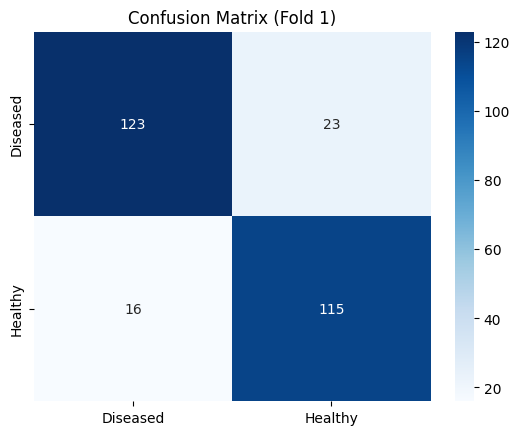

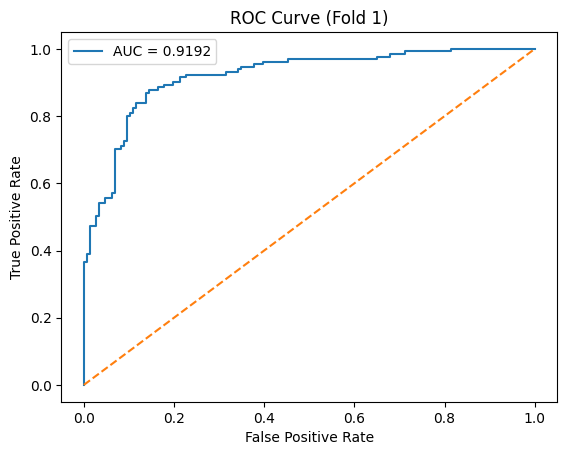

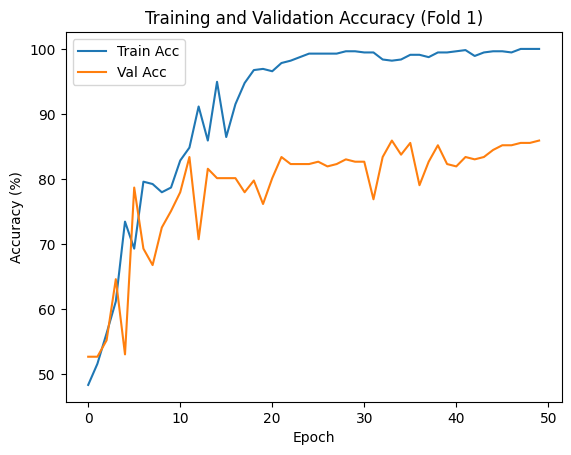

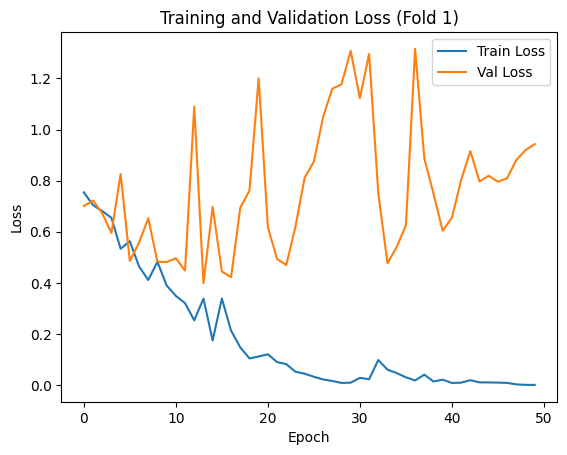


===== Fold 2 =====
Epoch [1/10], Train Acc: 51.8051%, Val Acc: 52.7076%
Epoch [2/10], Train Acc: 51.6245%, Val Acc: 47.2924%
Epoch [3/10], Train Acc: 53.6101%, Val Acc: 76.8953%
Epoch [4/10], Train Acc: 71.4801%, Val Acc: 78.7004%
Epoch [5/10], Train Acc: 57.7617%, Val Acc: 74.7292%
Epoch [6/10], Train Acc: 68.0505%, Val Acc: 69.6751%
Epoch [7/10], Train Acc: 74.3682%, Val Acc: 71.4801%
Epoch [8/10], Train Acc: 77.7978%, Val Acc: 80.8664%
Epoch [9/10], Train Acc: 78.1588%, Val Acc: 77.9783%
Epoch [10/10], Train Acc: 84.4765%, Val Acc: 82.3105%
Epoch [11/10], Train Acc: 87.5451%, Val Acc: 84.8375%
Epoch [12/10], Train Acc: 88.2671%, Val Acc: 81.9495%
Epoch [13/10], Train Acc: 87.3646%, Val Acc: 79.0614%
Epoch [14/10], Train Acc: 85.0181%, Val Acc: 80.5054%
Epoch [15/10], Train Acc: 87.0036%, Val Acc: 83.3935%
Epoch [16/10], Train Acc: 88.8087%, Val Acc: 85.9206%
Epoch [17/10], Train Acc: 93.6823%, Val Acc: 83.7545%
Epoch [18/10], Train Acc: 95.1264%, Val Acc: 84.8375%
Epoch [19/10], Tr

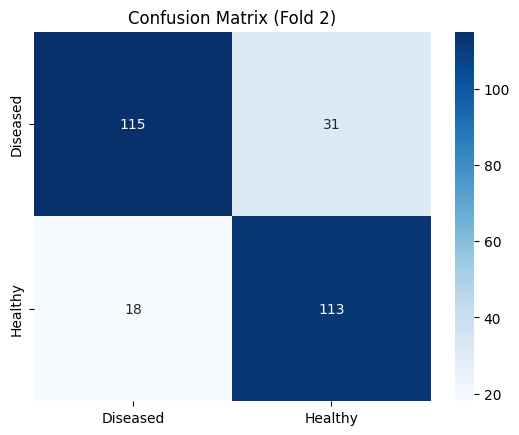

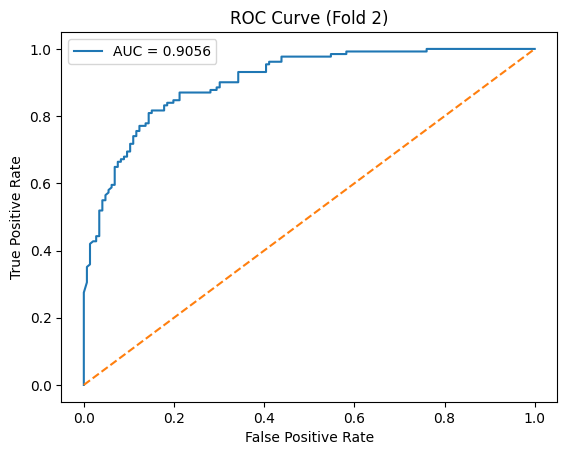

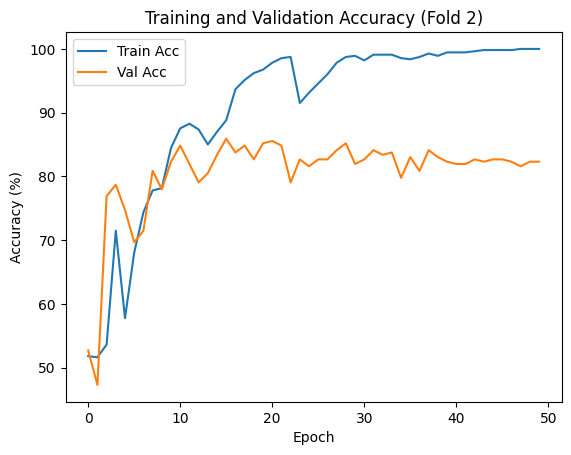

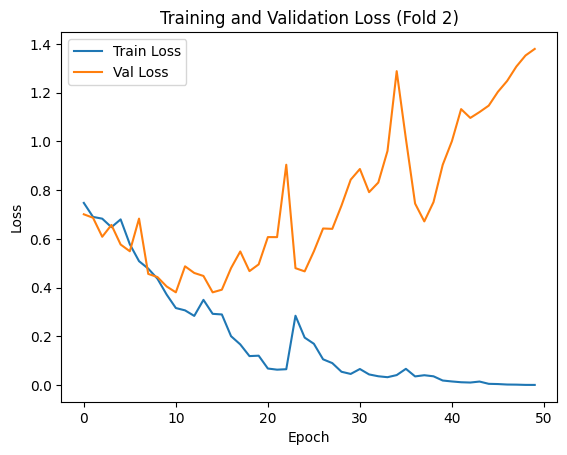


===== Fold 3 =====
Epoch [1/10], Train Acc: 52.3466%, Val Acc: 52.3466%
Epoch [2/10], Train Acc: 57.2202%, Val Acc: 53.0686%
Epoch [3/10], Train Acc: 50.9025%, Val Acc: 53.0686%
Epoch [4/10], Train Acc: 58.8448%, Val Acc: 57.7617%
Epoch [5/10], Train Acc: 56.4982%, Val Acc: 64.2599%
Epoch [6/10], Train Acc: 68.4116%, Val Acc: 68.2310%
Epoch [7/10], Train Acc: 73.8267%, Val Acc: 69.3141%
Epoch [8/10], Train Acc: 73.2852%, Val Acc: 66.7870%
Epoch [9/10], Train Acc: 79.4224%, Val Acc: 72.2022%
Epoch [10/10], Train Acc: 77.4368%, Val Acc: 70.0361%
Epoch [11/10], Train Acc: 76.7148%, Val Acc: 70.7581%
Epoch [12/10], Train Acc: 80.5054%, Val Acc: 74.7292%
Epoch [13/10], Train Acc: 71.4801%, Val Acc: 66.0650%
Epoch [14/10], Train Acc: 75.9928%, Val Acc: 73.6462%
Epoch [15/10], Train Acc: 80.3249%, Val Acc: 78.3394%
Epoch [16/10], Train Acc: 86.1011%, Val Acc: 77.9783%
Epoch [17/10], Train Acc: 88.6282%, Val Acc: 84.8375%
Epoch [18/10], Train Acc: 88.9892%, Val Acc: 79.7834%
Epoch [19/10], Tr

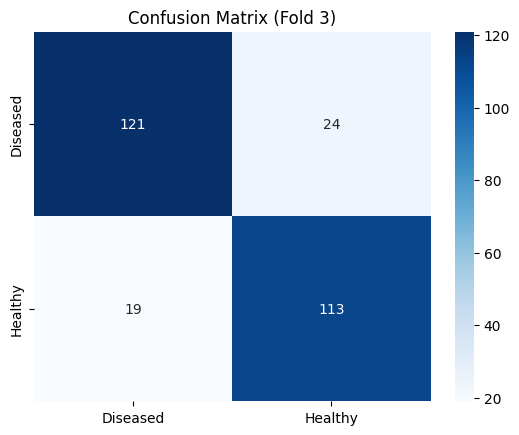

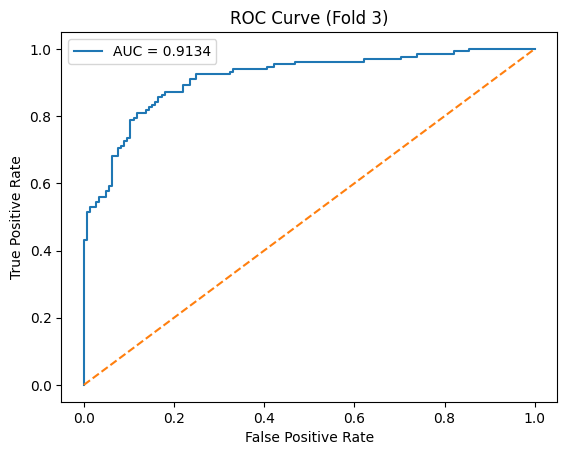

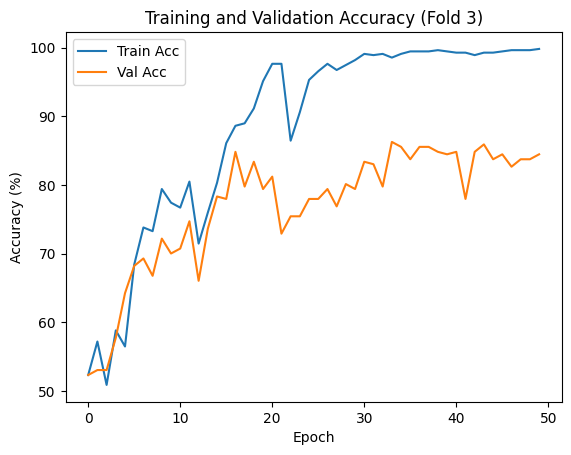

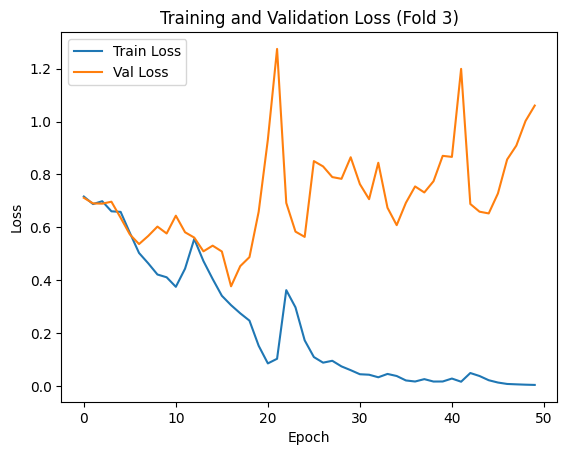


===== Cross-Validation Summary =====
Fold 1: Val Acc = 85.9206%, AUC = 0.9192
Fold 2: Val Acc = 82.3105%, AUC = 0.9056
Fold 3: Val Acc = 84.4765%, AUC = 0.9134

Average Val Accuracy: 84.2359%
Average AUC: 0.9128


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------
# 1. Define Vision Transformer
# ----------------------------
class PretrainedViT(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", num_classes=1):
        super().__init__()
        self.base_model = timm.create_model(model_name, pretrained=True)
        in_features = self.base_model.head.in_features
        self.base_model.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
            nn.Sigmoid()  # binary output
        )
    def forward(self, x):
        return self.base_model(x)

# ----------------------------
# 2. Data Loading
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# root folder containing two subfolders: Healthy, Diseased
dataset = datasets.ImageFolder("/content/drive/MyDrive/Chroma", transform=transform)

# Get labels for StratifiedKFold
labels = np.array([dataset.targets[i] for i in range(len(dataset))])

# ----------------------------
# 3. 5-Fold Cross-Validation
# ----------------------------
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n===== Fold {fold+1} =====")

    # Subset the dataset for this fold
    train_subset = Subset(dataset, train_idx)
    val_subset   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=100, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=100, shuffle=False)

    # Model, Loss, Optimizer
    model = PretrainedViT().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_acc, val_acc, train_loss, val_loss = [], [], [], []

    # ---------------- Training ----------------
    for epoch in range(50):  # adjust epochs as needed
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for imgs, labels_batch in train_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = (outputs > 0.5).int()
            correct += (preds == labels_batch.int()).sum().item()
            total += labels_batch.size(0)

        train_acc.append(100 * correct / total)
        train_loss.append(epoch_loss / len(train_loader))

        # Validation
        model.eval()
        correct, total, epoch_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels_batch in val_loader:
                imgs, labels_batch = imgs.to(device), labels_batch.to(device).float().unsqueeze(1)
                outputs = model(imgs)
                loss = criterion(outputs, labels_batch)

                epoch_loss += loss.item()
                preds = (outputs > 0.5).int()
                correct += (preds == labels_batch.int()).sum().item()
                total += labels_batch.size(0)

        val_acc.append(100 * correct / total)
        val_loss.append(epoch_loss / len(val_loader))

        print(f"Epoch [{epoch+1}/10], Train Acc: {train_acc[-1]:.4f}%, Val Acc: {val_acc[-1]:.4f}%")

    # ---------------- Evaluation ----------------
    y_true, y_pred, y_scores = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy().ravel()
            preds = (outputs > 0.5).astype(int)
            y_scores.extend(outputs)
            y_pred.extend(preds)
            y_true.extend(labels_batch.numpy())

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=dataset.classes, digits=4))
    print(f'Classification Report for Best Epoch (Fold {fold + 1}):\n')
    # print(classification_report(best_y_true, best_y_pred, target_names=["HC", "PD"], digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
    plt.title(f"Confusion Matrix (Fold {fold+1})")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Accuracy curves
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Training and Validation Accuracy (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Loss curves
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Save fold results
    fold_results.append({
        "fold": fold+1,
        "val_acc": val_acc[-1],
        "roc_auc": roc_auc
    })

# ----------------------------
# 4. Final Summary
# ----------------------------
print("\n===== Cross-Validation Summary =====")
for r in fold_results:
    print(f"Fold {r['fold']}: Val Acc = {r['val_acc']:.4f}%, AUC = {r['roc_auc']:.4f}")

mean_acc = np.mean([r["val_acc"] for r in fold_results])
mean_auc = np.mean([r["roc_auc"] for r in fold_results])
print(f"\nAverage Val Accuracy: {mean_acc:.4f}%")
print(f"Average AUC: {mean_auc:.4f}")


MEL


===== Fold 1 =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Epoch [1/10], Train Acc: 51.5464%, Val Acc: 50.3425%
Epoch [2/10], Train Acc: 50.5155%, Val Acc: 50.0000%
Epoch [3/10], Train Acc: 51.7182%, Val Acc: 50.0000%
Epoch [4/10], Train Acc: 52.5773%, Val Acc: 50.0000%
Epoch [5/10], Train Acc: 50.0000%, Val Acc: 48.9726%
Epoch [6/10], Train Acc: 47.4227%, Val Acc: 50.0000%
Epoch [7/10], Train Acc: 54.4674%, Val Acc: 50.0000%
Epoch [8/10], Train Acc: 50.5155%, Val Acc: 50.0000%
Epoch [9/10], Train Acc: 51.0309%, Val Acc: 49.3151%
Epoch [10/10], Train Acc: 49.8282%, Val Acc: 50.0000%
Epoch [11/10], Train Acc: 48.1100%, Val Acc: 49.6575%
Epoch [12/10], Train Acc: 47.9381%, Val Acc: 46.2329%
Epoch [13/10], Train Acc: 47.5945%, Val Acc: 50.6849%

Classification Report:
               precision    recall  f1-score   support

diseased_out     0.6250    0.0342    0.0649       146
 healthy_out     0.5035    0.9795    0.6651       146

    accuracy                         0.5068       292
   macro avg     0.5643    0.5068    0.3650       292
weighted a

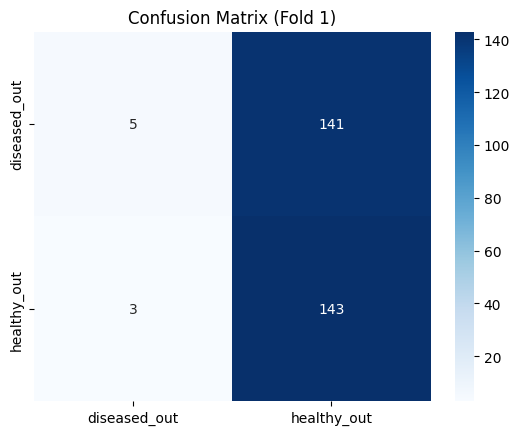

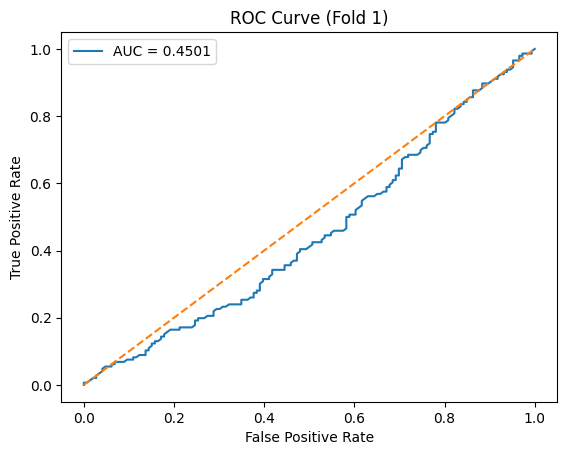

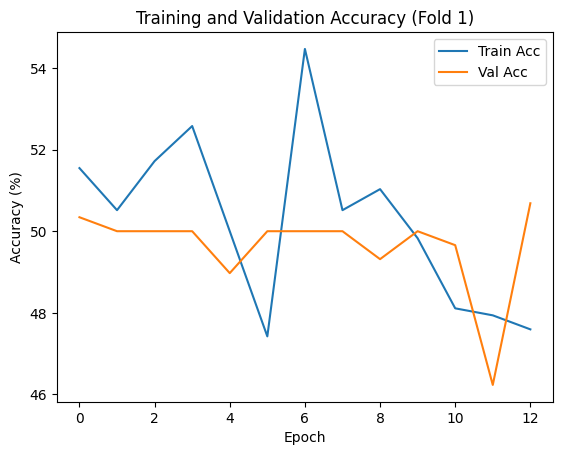

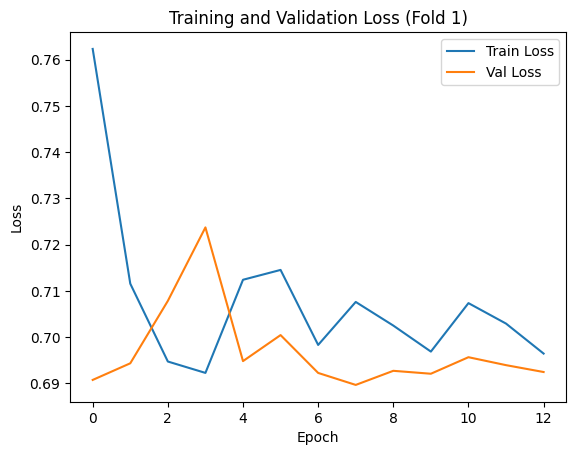


===== Fold 2 =====
Epoch [1/10], Train Acc: 47.8559%, Val Acc: 49.4845%
Epoch [2/10], Train Acc: 47.3413%, Val Acc: 49.8282%
Epoch [3/10], Train Acc: 49.9142%, Val Acc: 50.1718%
Epoch [4/10], Train Acc: 51.9726%, Val Acc: 49.8282%
Epoch [5/10], Train Acc: 50.7719%, Val Acc: 50.1718%
Epoch [6/10], Train Acc: 47.8559%, Val Acc: 50.1718%
Epoch [7/10], Train Acc: 51.1149%, Val Acc: 50.1718%
Epoch [8/10], Train Acc: 54.0309%, Val Acc: 41.2371%
Epoch [9/10], Train Acc: 46.4837%, Val Acc: 40.8935%
Epoch [10/10], Train Acc: 47.3413%, Val Acc: 49.8282%
Epoch [11/10], Train Acc: 47.8559%, Val Acc: 47.7663%
Epoch [12/10], Train Acc: 49.9142%, Val Acc: 49.8282%
Epoch [13/10], Train Acc: 52.6587%, Val Acc: 47.0790%

Classification Report:
               precision    recall  f1-score   support

diseased_out     0.4833    0.7945    0.6010       146
 healthy_out     0.4118    0.1448    0.2143       145

    accuracy                         0.4708       291
   macro avg     0.4475    0.4697    0.4077 

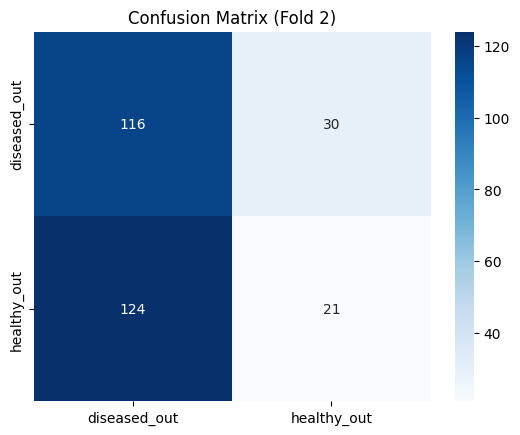

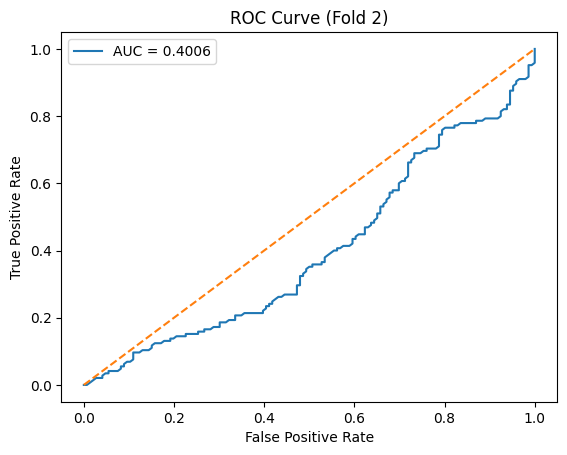

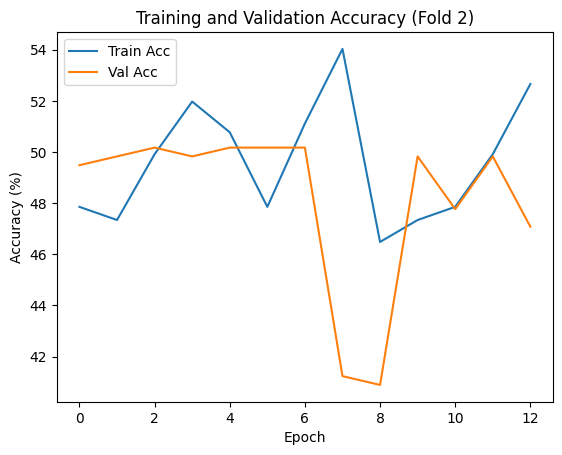

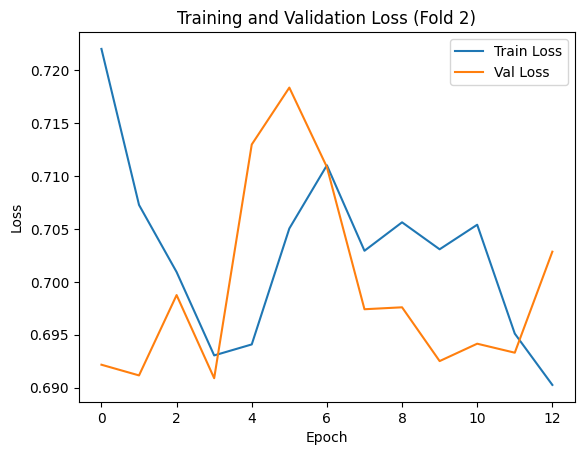


===== Fold 3 =====
Epoch [1/10], Train Acc: 50.4288%, Val Acc: 49.8282%
Epoch [2/10], Train Acc: 50.4288%, Val Acc: 49.8282%
Epoch [3/10], Train Acc: 50.9434%, Val Acc: 49.8282%
Epoch [4/10], Train Acc: 49.2281%, Val Acc: 43.2990%
Epoch [5/10], Train Acc: 50.6003%, Val Acc: 49.8282%
Epoch [6/10], Train Acc: 48.7136%, Val Acc: 49.8282%
Epoch [7/10], Train Acc: 49.2281%, Val Acc: 50.1718%
Epoch [8/10], Train Acc: 50.0858%, Val Acc: 46.0481%
Epoch [9/10], Train Acc: 51.8010%, Val Acc: 49.8282%
Epoch [10/10], Train Acc: 48.5420%, Val Acc: 47.4227%
Epoch [11/10], Train Acc: 51.8010%, Val Acc: 49.8282%
Epoch [12/10], Train Acc: 51.9726%, Val Acc: 45.3608%
Epoch [13/10], Train Acc: 51.8010%, Val Acc: 47.7663%

Classification Report:
               precision    recall  f1-score   support

diseased_out     0.4857    0.8207    0.6103       145
 healthy_out     0.4348    0.1370    0.2083       146

    accuracy                         0.4777       291
   macro avg     0.4602    0.4788    0.4093 

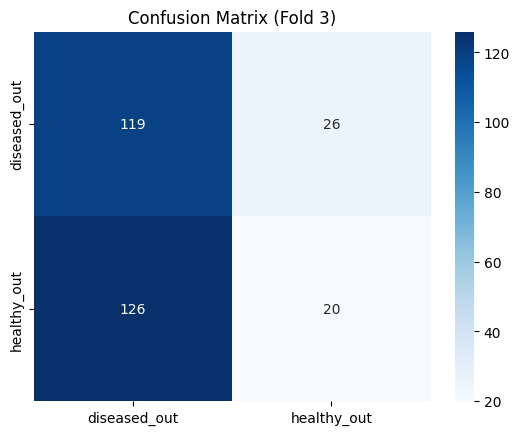

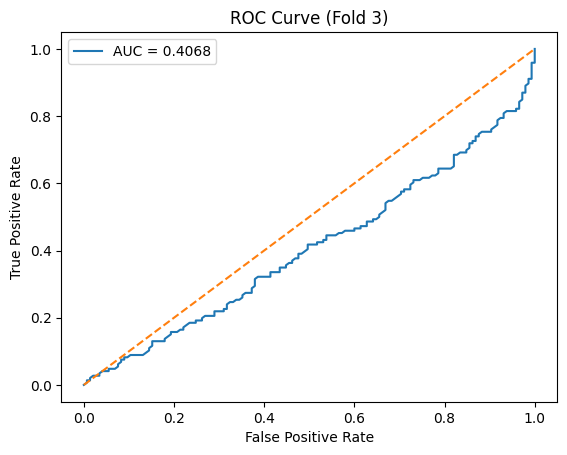

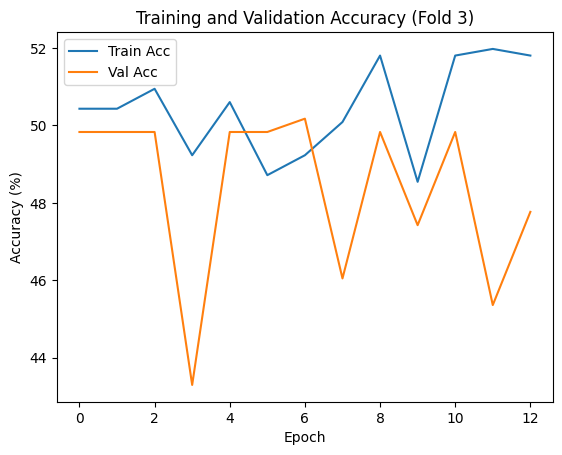

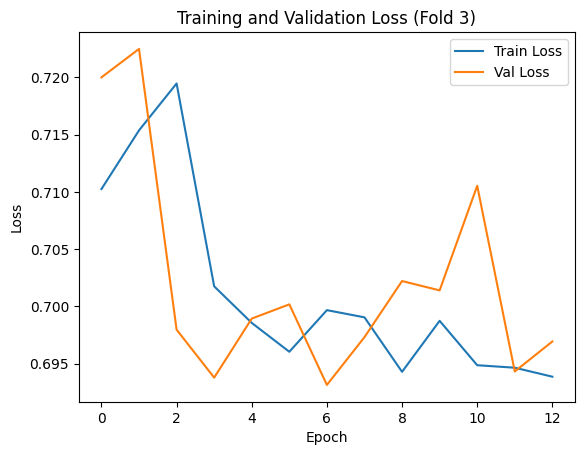


===== Cross-Validation Summary =====
Fold 1: Val Acc = 50.6849%, AUC = 0.4501
Fold 2: Val Acc = 47.0790%, AUC = 0.4006
Fold 3: Val Acc = 47.7663%, AUC = 0.4068

Average Val Accuracy: 48.5101%
Average AUC: 0.4192


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import timm

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------
# 1. Define Vision Transformer
# ----------------------------
class PretrainedViT(nn.Module):
    def __init__(self, model_name="vit_base_patch16_224", num_classes=1):
        super().__init__()
        self.base_model = timm.create_model(model_name, pretrained=True)
        in_features = self.base_model.head.in_features
        self.base_model.head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
            nn.Sigmoid()  # binary output
        )
    def forward(self, x):
        return self.base_model(x)

# ----------------------------
# 2. Data Loading
# ----------------------------
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# root folder containing two subfolders: Healthy, Diseased
dataset = datasets.ImageFolder("/content/drive/MyDrive/PD", transform=transform)

# Get labels for StratifiedKFold
labels = np.array([dataset.targets[i] for i in range(len(dataset))])

# ----------------------------
# 3. 5-Fold Cross-Validation
# ----------------------------
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(labels)), labels)):
    print(f"\n===== Fold {fold+1} =====")

    # Subset the dataset for this fold
    train_subset = Subset(dataset, train_idx)
    val_subset   = Subset(dataset, val_idx)

    train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)

    # Model, Loss, Optimizer
    model = PretrainedViT().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    train_acc, val_acc, train_loss, val_loss = [], [], [], []

    # ---------------- Training ----------------
    for epoch in range(13):  # adjust epochs as needed
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        for imgs, labels_batch in train_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device).float().unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels_batch)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            preds = (outputs > 0.5).int()
            correct += (preds == labels_batch.int()).sum().item()
            total += labels_batch.size(0)

        train_acc.append(100 * correct / total)
        train_loss.append(epoch_loss / len(train_loader))

        # Validation
        model.eval()
        correct, total, epoch_loss = 0, 0, 0
        with torch.no_grad():
            for imgs, labels_batch in val_loader:
                imgs, labels_batch = imgs.to(device), labels_batch.to(device).float().unsqueeze(1)
                outputs = model(imgs)
                loss = criterion(outputs, labels_batch)

                epoch_loss += loss.item()
                preds = (outputs > 0.5).int()
                correct += (preds == labels_batch.int()).sum().item()
                total += labels_batch.size(0)

        val_acc.append(100 * correct / total)
        val_loss.append(epoch_loss / len(val_loader))

        print(f"Epoch [{epoch+1}/10], Train Acc: {train_acc[-1]:.4f}%, Val Acc: {val_acc[-1]:.4f}%")

    # ---------------- Evaluation ----------------
    y_true, y_pred, y_scores = [], [], []
    model.eval()
    with torch.no_grad():
        for imgs, labels_batch in val_loader:
            imgs = imgs.to(device)
            outputs = model(imgs).cpu().numpy().ravel()
            preds = (outputs > 0.5).astype(int)
            y_scores.extend(outputs)
            y_pred.extend(preds)
            y_true.extend(labels_batch.numpy())

    # Classification Report
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=dataset.classes, digits=4))
    print(f'Classification Report for Best Epoch (Fold {fold + 1}):\n')
    # print(classification_report(best_y_true, best_y_pred, target_names=["HC", "PD"], digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
    plt.title(f"Confusion Matrix (Fold {fold+1})")
    plt.show()

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Accuracy curves
    plt.plot(train_acc, label="Train Acc")
    plt.plot(val_acc, label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"Training and Validation Accuracy (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Loss curves
    plt.plot(train_loss, label="Train Loss")
    plt.plot(val_loss, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss (Fold {fold+1})")
    plt.legend()
    plt.show()

    # Save fold results
    fold_results.append({
        "fold": fold+1,
        "val_acc": val_acc[-1],
        "roc_auc": roc_auc
    })

# ----------------------------
# 4. Final Summary
# ----------------------------
print("\n===== Cross-Validation Summary =====")
for r in fold_results:
    print(f"Fold {r['fold']}: Val Acc = {r['val_acc']:.4f}%, AUC = {r['roc_auc']:.4f}")

mean_acc = np.mean([r["val_acc"] for r in fold_results])
mean_auc = np.mean([r["roc_auc"] for r in fold_results])
print(f"\nAverage Val Accuracy: {mean_acc:.4f}%")
print(f"Average AUC: {mean_auc:.4f}")
